Shape: (284807, 31)

Class distribution:
0    284315
1       492
Name: Class, dtype: int64

Percentage:
0    99.827251
1     0.172749
Name: Class, dtype: float64


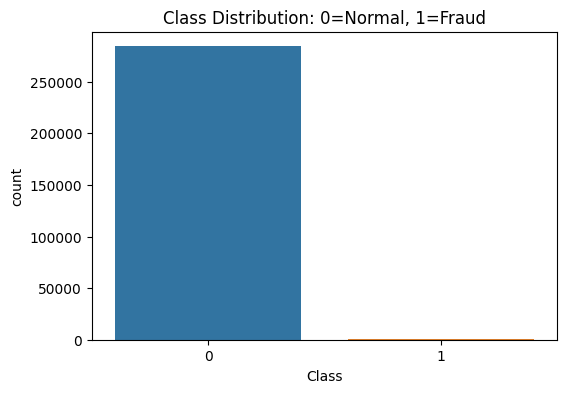

In [7]:
#load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution: 0=Normal, 1=Fraud')
plt.show()

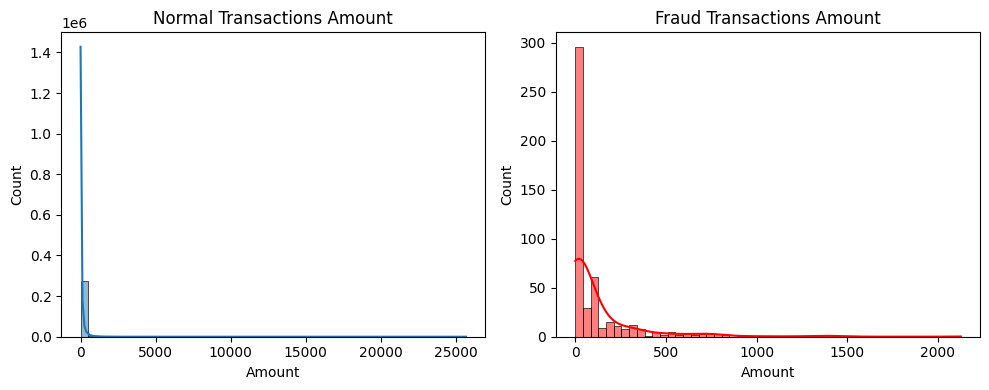

Correlation of Amount with Class: 0.005631753006768552


In [8]:
#  EDA
df.describe()
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], bins=50, kde=True)
plt.title('Normal Transactions Amount')
plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, kde=True, color='red')
plt.title('Fraud Transactions Amount')
plt.tight_layout()
plt.show()
print("Correlation of Amount with Class:", df[['Amount','Class']].corr().iloc[0,1])

In [9]:
# prep data
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
print("Train shape:", X_train.shape)
print("Test fraud cases:", sum(y_test))

Train shape: (227845, 30)
Test fraud cases: 98


In [10]:
#train model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
print("Training Logistic Regression...")
lr.fit(X_train, y_train)
print("Training Random Forest...")
rf.fit(X_train, y_train)
print("Models trained")

Training Logistic Regression...
Training Random Forest...
Models trained


In [13]:
# Evaluate
models = {'Logistic Regression': lr, 'Random Forest': rf}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print("="*60)
    print(f"{name}")
    print("="*60)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {round(roc_auc_score(y_test, y_prob), 4)}")
    print("\n")

Logistic Regression
Confusion Matrix:
[[55478  1386]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9721


Random Forest
Confusion Matrix:
[[56861     3]
 [   25    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9529




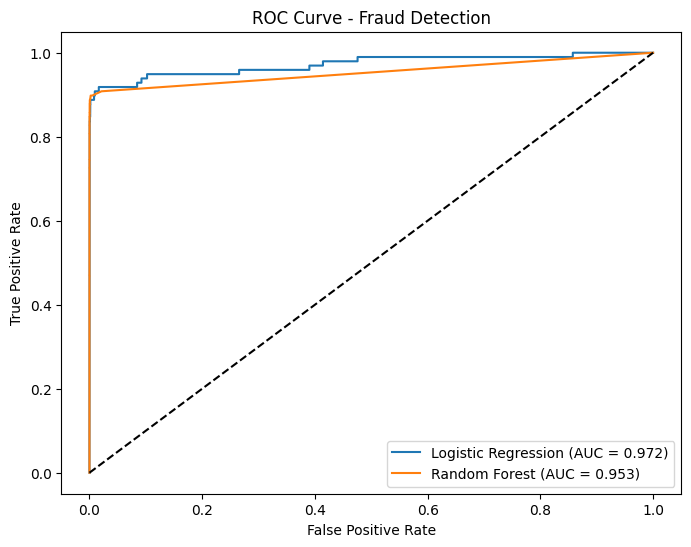

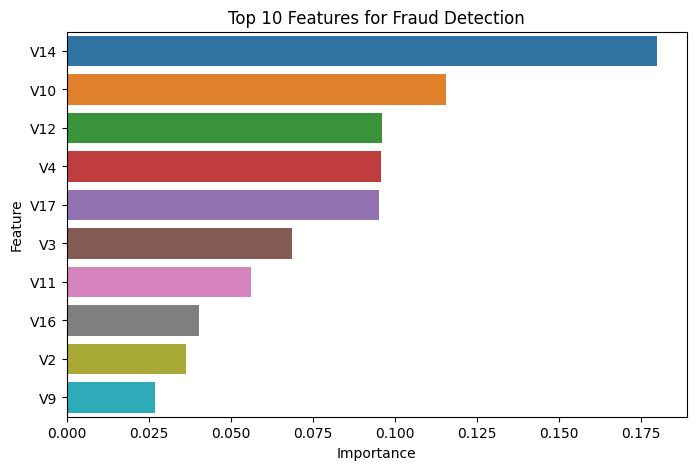

In [14]:
#ROC Curve
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fraud Detection')
plt.legend()
plt.show()
importances = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Top 10 Features for Fraud Detection')
plt.show()